# Object Detection using YOLO on X-Ray Images of Luggage

Imports

In [42]:
# !pip3 install ultralytics

In [ ]:
import kagglehub
import os
import numpy as np

import matplotlib.pyplot as plt
import cv2
import time

import yaml
import shutil


from ultralytics import YOLO

In [4]:
# download the dataset
path = kagglehub.dataset_download("orvile/x-ray-baggage-anomaly-detection")

print("Path to dataset files:", path)

Path to dataset files: /Users/estefanialaverdebecerra/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1


## Dataset Exploration

In [5]:
# check the contents of the path
print("Contents of dataset path:", os.listdir(path))

Contents of dataset path: ['README.roboflow.txt', 'valid', 'README.dataset.txt', 'test', 'data.yaml', 'train']


In [19]:
# set train, validation and test paths
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "valid")
test_path = os.path.join(path, "test")

# show the contents of the train path
print("Contents of train path:", os.listdir(train_path))

Contents of train path: ['images', 'labels']


In [30]:
# show the contents of the images and labels folders in the train path
print("Contents of train images path:", os.listdir(os.path.join(train_path, "images"))[:3])
print("Contents of train labels path:", os.listdir(os.path.join(train_path, "labels"))[:3])

# print number of images and labels in the train path
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_train_labels = len(os.listdir(os.path.join(train_path, "labels")))
print(f"Number of training images: {num_train_images}")
print(f"Number of training labels: {num_train_labels}")

Contents of train images path: ['039442_jpg.rf.8847d97b242f97ed96d937c4226b159a.jpg', '042973_jpg.rf.6792837ba2183435721cd7b4e9674ecd.jpg', '038679_jpg.rf.5971cc9e13635a2105174621f731f1df.jpg']
Contents of train labels path: ['026242_jpg.rf.d1fcb37b37aba094f960b21572f4727c.txt', '036263_jpg.rf.5a6d29813aefd6550e523387741418c2.txt', '024316_jpg.rf.bee2c2b06f4ea70340862ea8aae3649b.txt']
Number of training images: 6181
Number of training labels: 6181


Each image has a corresponding txt file with the same name in the labels folder. Lets inspect one of the images and its corresponding label file.

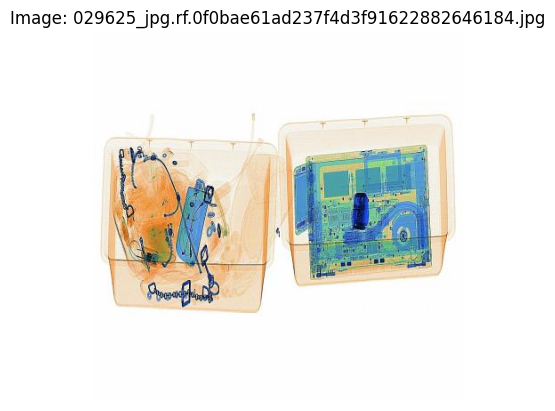

Contents of label file 029625_jpg.rf.0f0bae61ad237f4d3f91622882646184.txt:
4 0.7259615384615384 0.49399038461538464 0.09254807692307693 0.12740384615384615


In [27]:
# select an image and its corresponding label file
image_file = os.listdir(os.path.join(train_path, "images"))[20]
label_file = image_file.replace(".jpg", ".txt")

# read the image
image = cv2.imread(os.path.join(train_path, "images", image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# read the label file
with open(os.path.join(train_path, "labels", label_file), "r") as f:
    label_contents = f.read()

# plot the image
plt.imshow(image)
plt.title(f"Image: {image_file}")
plt.axis("off")
plt.show()

# print the contents
print(f"Contents of label file {label_file}:\n{label_contents}")

Each label file contains 4 numbers corresponding to:
- class id
- center x coordinate of the bounding box (normalized by image width)
- center y coordinate of the bounding box (normalized by image height)
- width of the bounding box (normalized by image width)
- height of the bounding box (normalized by image height)

Let's visualize the bounding box on top of the image to better understand the format of the label files.

In [28]:
def draw_yolo_bbox(image_path, label_data):
    img = cv2.imread(image_path)
    # Convert BGR to RGB 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _ = img.shape
    
    for line in label_data.splitlines():
        # extract data from label
        _, x, y, w, h = map(float, line.split())
        print(f"Label data - x: {x}, y: {y}, w: {w}, h: {h}")
        
        # convert normalized coordinates to pixel values
        center_x, center_y = int(x * W), int(y * H)
        width, height = int(w * W), int(h * H)
        
        # compute top-left and bottom-right corners of the bounding box
        xmin = int(center_x - (width / 2))
        ymin = int(center_y - (height / 2))
        xmax = int(center_x + (width / 2))
        ymax = int(center_y + (height / 2))
        
        # plot on top of the image (rectangle in red)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Objetos Prohibidos Detectados")
    plt.axis('off') 
    plt.show()

Label data - x: 0.7259615384615384, y: 0.49399038461538464, w: 0.09254807692307693, h: 0.12740384615384615


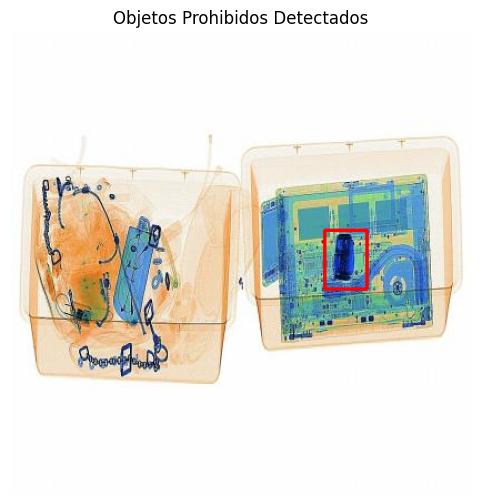

In [29]:
draw_yolo_bbox(os.path.join(train_path, "images", image_file), label_contents)

In [21]:
# count the number of images in each set
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_val_images = len(os.listdir(os.path.join(val_path, "images")))
num_test_images = len(os.listdir(os.path.join(test_path, "images")))

print(f"Number of training images: {num_train_images}")
print(f"Number of validation images: {num_val_images}")
print(f"Number of test images: {num_test_images}")

Number of training images: 6181
Number of validation images: 1766
Number of test images: 883


In [22]:
# average number of objects per image in each set
def average_objects_per_image(label_path):
    total_objects = 0
    total_images = 0
    
    for label_file in os.listdir(label_path):
        with open(os.path.join(label_path, label_file), "r") as f:
            lines = f.readlines()
            total_objects += len(lines)
            total_images += 1
            
    return total_objects / total_images if total_images > 0 else 0

avg_objects_train = average_objects_per_image(os.path.join(train_path, "labels"))
avg_objects_val = average_objects_per_image(os.path.join(val_path, "labels"))
avg_objects_test = average_objects_per_image(os.path.join(test_path, "labels"))

print(f"Average number of objects per image in training set: {avg_objects_train:.2f}")
print(f"Average number of objects per image in validation set: {avg_objects_val:.2f}")
print(f"Average number of objects per image in test set: {avg_objects_test:.2f}")

Average number of objects per image in training set: 1.00
Average number of objects per image in validation set: 1.00
Average number of objects per image in test set: 1.00


In [35]:
# mean and std dev of image dimensions in each set
def average_image_dimensions(image_path):
    widths = []
    heights = []
    
    for image_file in os.listdir(image_path):
        img = cv2.imread(os.path.join(image_path, image_file))
        if img is not None:
            h, w, _ = img.shape
            widths.append(w)
            heights.append(h)
            
    if not widths:
        return 0, 0, 0, 0

    # compute mean values
    avg_width = np.mean(widths)
    avg_height = np.mean(heights)
    
    # compute standard deviation values
    std_width = np.std(widths)
    std_height = np.std(heights)
    
    return avg_width, avg_height, std_width, std_height

In [36]:
avg_w_train, avg_h_train, std_w_train, std_h_train = average_image_dimensions(os.path.join(train_path, "images"))
avg_w_val, avg_h_val, std_w_val, std_h_val = average_image_dimensions(os.path.join(val_path, "images"))
avg_w_test, avg_h_test, std_w_test, std_h_test = average_image_dimensions(os.path.join(test_path, "images"))

print(f"Training set - Average width: {avg_w_train:.2f}, Average height: {avg_h_train:.2f}, Std width: {std_w_train:.2f}, Std height: {std_h_train:.2f}")
print(f"Validation set - Average width: {avg_w_val:.2f}, Average height: {avg_h_val:.2f}, Std width: {std_w_val:.2f}, Std height: {std_h_val:.2f}")
print(f"Test set - Average width: {avg_w_test:.2f}, Average height: {avg_h_test:.2f}, Std width: {std_w_test:.2f}, Std height: {std_h_test:.2f}")

Training set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00
Validation set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00
Test set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00


All images are sized 416x416 pixels and have at most one proihibited item.

## Image Preprocessing

In [37]:
def preprocess_xray(img):
    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    
    # sharpening the image
    gaussian_blur = cv2.GaussianBlur(img_clahe, (9, 9), 10.0)
    img_sharp = cv2.addWeighted(img_clahe, 1.5, gaussian_blur, -0.5, 0)
    
    return img_sharp

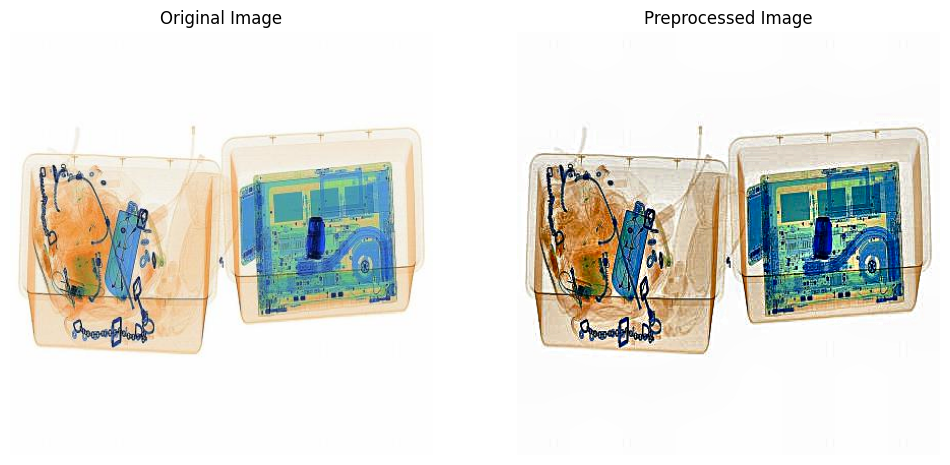

In [38]:
# plot original and preprocessed image side by side
original_img = cv2.imread(os.path.join(train_path, "images", image_file))
preprocessed_img = preprocess_xray(original_img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(preprocessed_img, cv2.COLOR_BGR2RGB))
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

Apply the preprocessing function to all images in every dataset split.

In [39]:
def apply_preprocessing_to_folder(src_path, dest_path):
    os.makedirs(dest_path, exist_ok=True)
    for img_name in os.listdir(src_path):
        img = cv2.imread(os.path.join(src_path, img_name))
        if img is not None:
            processed = preprocess_xray(img)
            cv2.imwrite(os.path.join(dest_path, img_name), processed)

# apply to train, val and test
train_images_proc = os.path.join(path, "train_processed", "images")
val_images_proc = os.path.join(path, "valid_processed", "images")
test_images_proc = os.path.join(path, "test_processed", "images")

# count time taken for preprocessing
print("Preprocessing images")
start_time = time.time()
apply_preprocessing_to_folder(os.path.join(train_path, "images"), train_images_proc)
apply_preprocessing_to_folder(os.path.join(val_path, "images"), val_images_proc)
apply_preprocessing_to_folder(os.path.join(test_path, "images"), test_images_proc)
end_time = time.time()
print(f"Preprocessing completed in {end_time - start_time:.2f} seconds")

Preprocessing images
Preprocessing completed in 13.27 seconds


## YOLOv11s Model Training

Configure the yaml file. This initial configuration takes the default values for all parameters except for the number of classes and the paths to the training and validation datasets. We will use the default hyperparameters for training, which are optimized for small datasets.

In [ ]:
data_config = {
    'train': train_images_proc.replace("/images", ""),
    'val': val_images_proc.replace("/images", ""),
    'test': test_images_proc.replace("/images", ""),
    'nc': 5,
    'names': ['0', '1', '2', '3', '4']
}

with open('xray_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

# copy label files to the processed folders
for p in ["train", "valid", "test"]:
    shutil.copytree(os.path.join(path, p, "labels"), os.path.join(path, f"{p}_processed", "labels"), dirs_exist_ok=True)

In [45]:
# Cargamos el modelo YOLOv11 nano
model = YOLO('yolo11n.pt') 

# Entrenamos
results = model.train(
    data='xray_data.yaml',
    epochs=50,
    imgsz=416,
    batch=16,
    name='yolo11_xray_results',
    device="mps",
    patience=10,
    # Aumentación de datos "al vuelo"
    hsv_h=0.015,  # ajuste de tono
    hsv_s=0.7,    # ajuste de saturación
    hsv_v=0.4,    # ajuste de brillo
    degrees=10.0, # rotación aleatoria
    translate=0.1,# traslación
    scale=0.5,    # escala
    flipud=0.0,   # flip vertical
    fliplr=0.5,   # flip horizontal
    mosaic=1.0    # técnica mosaic (muy útil en rayos x)
)

Ultralytics 8.4.48 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=xray_data.yaml, degrees=10.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_xray_results-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plot

In [ ]:
# 1. Visualizar curvas de entrenamiento
from IPython.display import Image as DisplayImage

# Las gráficas se guardan en runs/detect/yolo11_xray_results-3/
results_path = 'runs/detect/yolo11_xray_results-3/'
DisplayImage(filename=f'{results_path}results.png', width=800)

# 2. Matriz de Confusión
DisplayImage(filename=f'{results_path}confusion_matrix.png', width=800)

# 3. Validación final con el set de Test para sacar el mAP
metrics = model.val(data='xray_data.yaml', split='test')

print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.48 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M4)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 192.9±85.4 MB/s, size: 39.4 KB)
val: Scanning /Users/estefanialaverdebecerra/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/labels... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 7.3Kit/s 0.1s0.1s
val: New cache created: /Users/estefanialaverdebecerra/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 1.1it/s 48.8s0.9ss
                   all        883        883       0.85      0.766      0.845      0.384
                     0        166        166      0.861      0.982      0.982      0.493
                     1        193        193      0.844      0.782      0.85

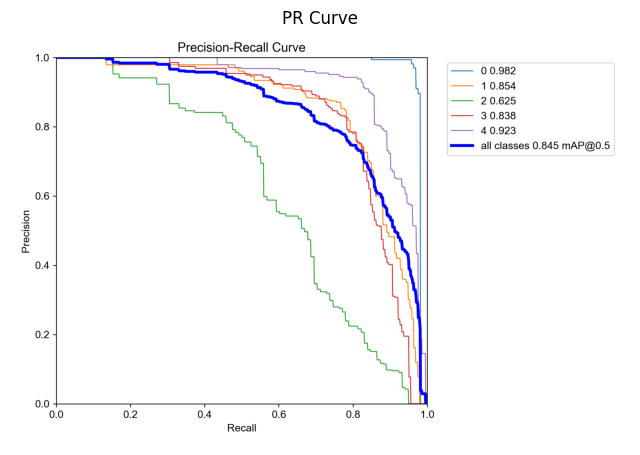

In [ ]:
# show box PR curve
pr_curve_path = 'runs/detect/val/BoxPR_curve.png'
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(cv2.imread(pr_curve_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB))
plt.title("Box PR Curve")
plt.axis("off")
plt.show()

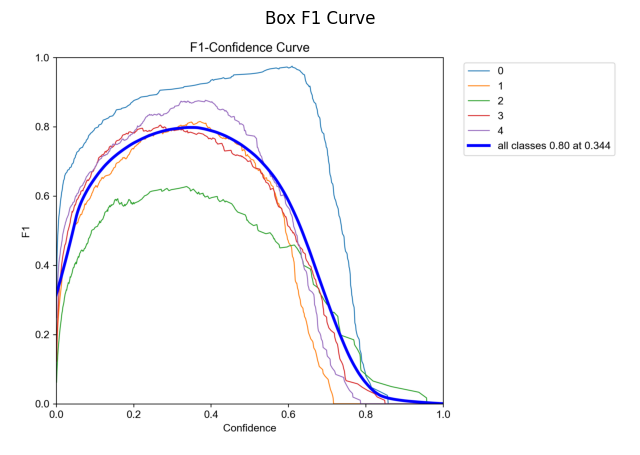

In [56]:
# show box f1 curve
f1_curve_path = 'runs/detect/val/BoxF1_curve.png'
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(cv2.imread(f1_curve_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB))
plt.title("Box F1 Curve")
plt.axis("off")
plt.show()

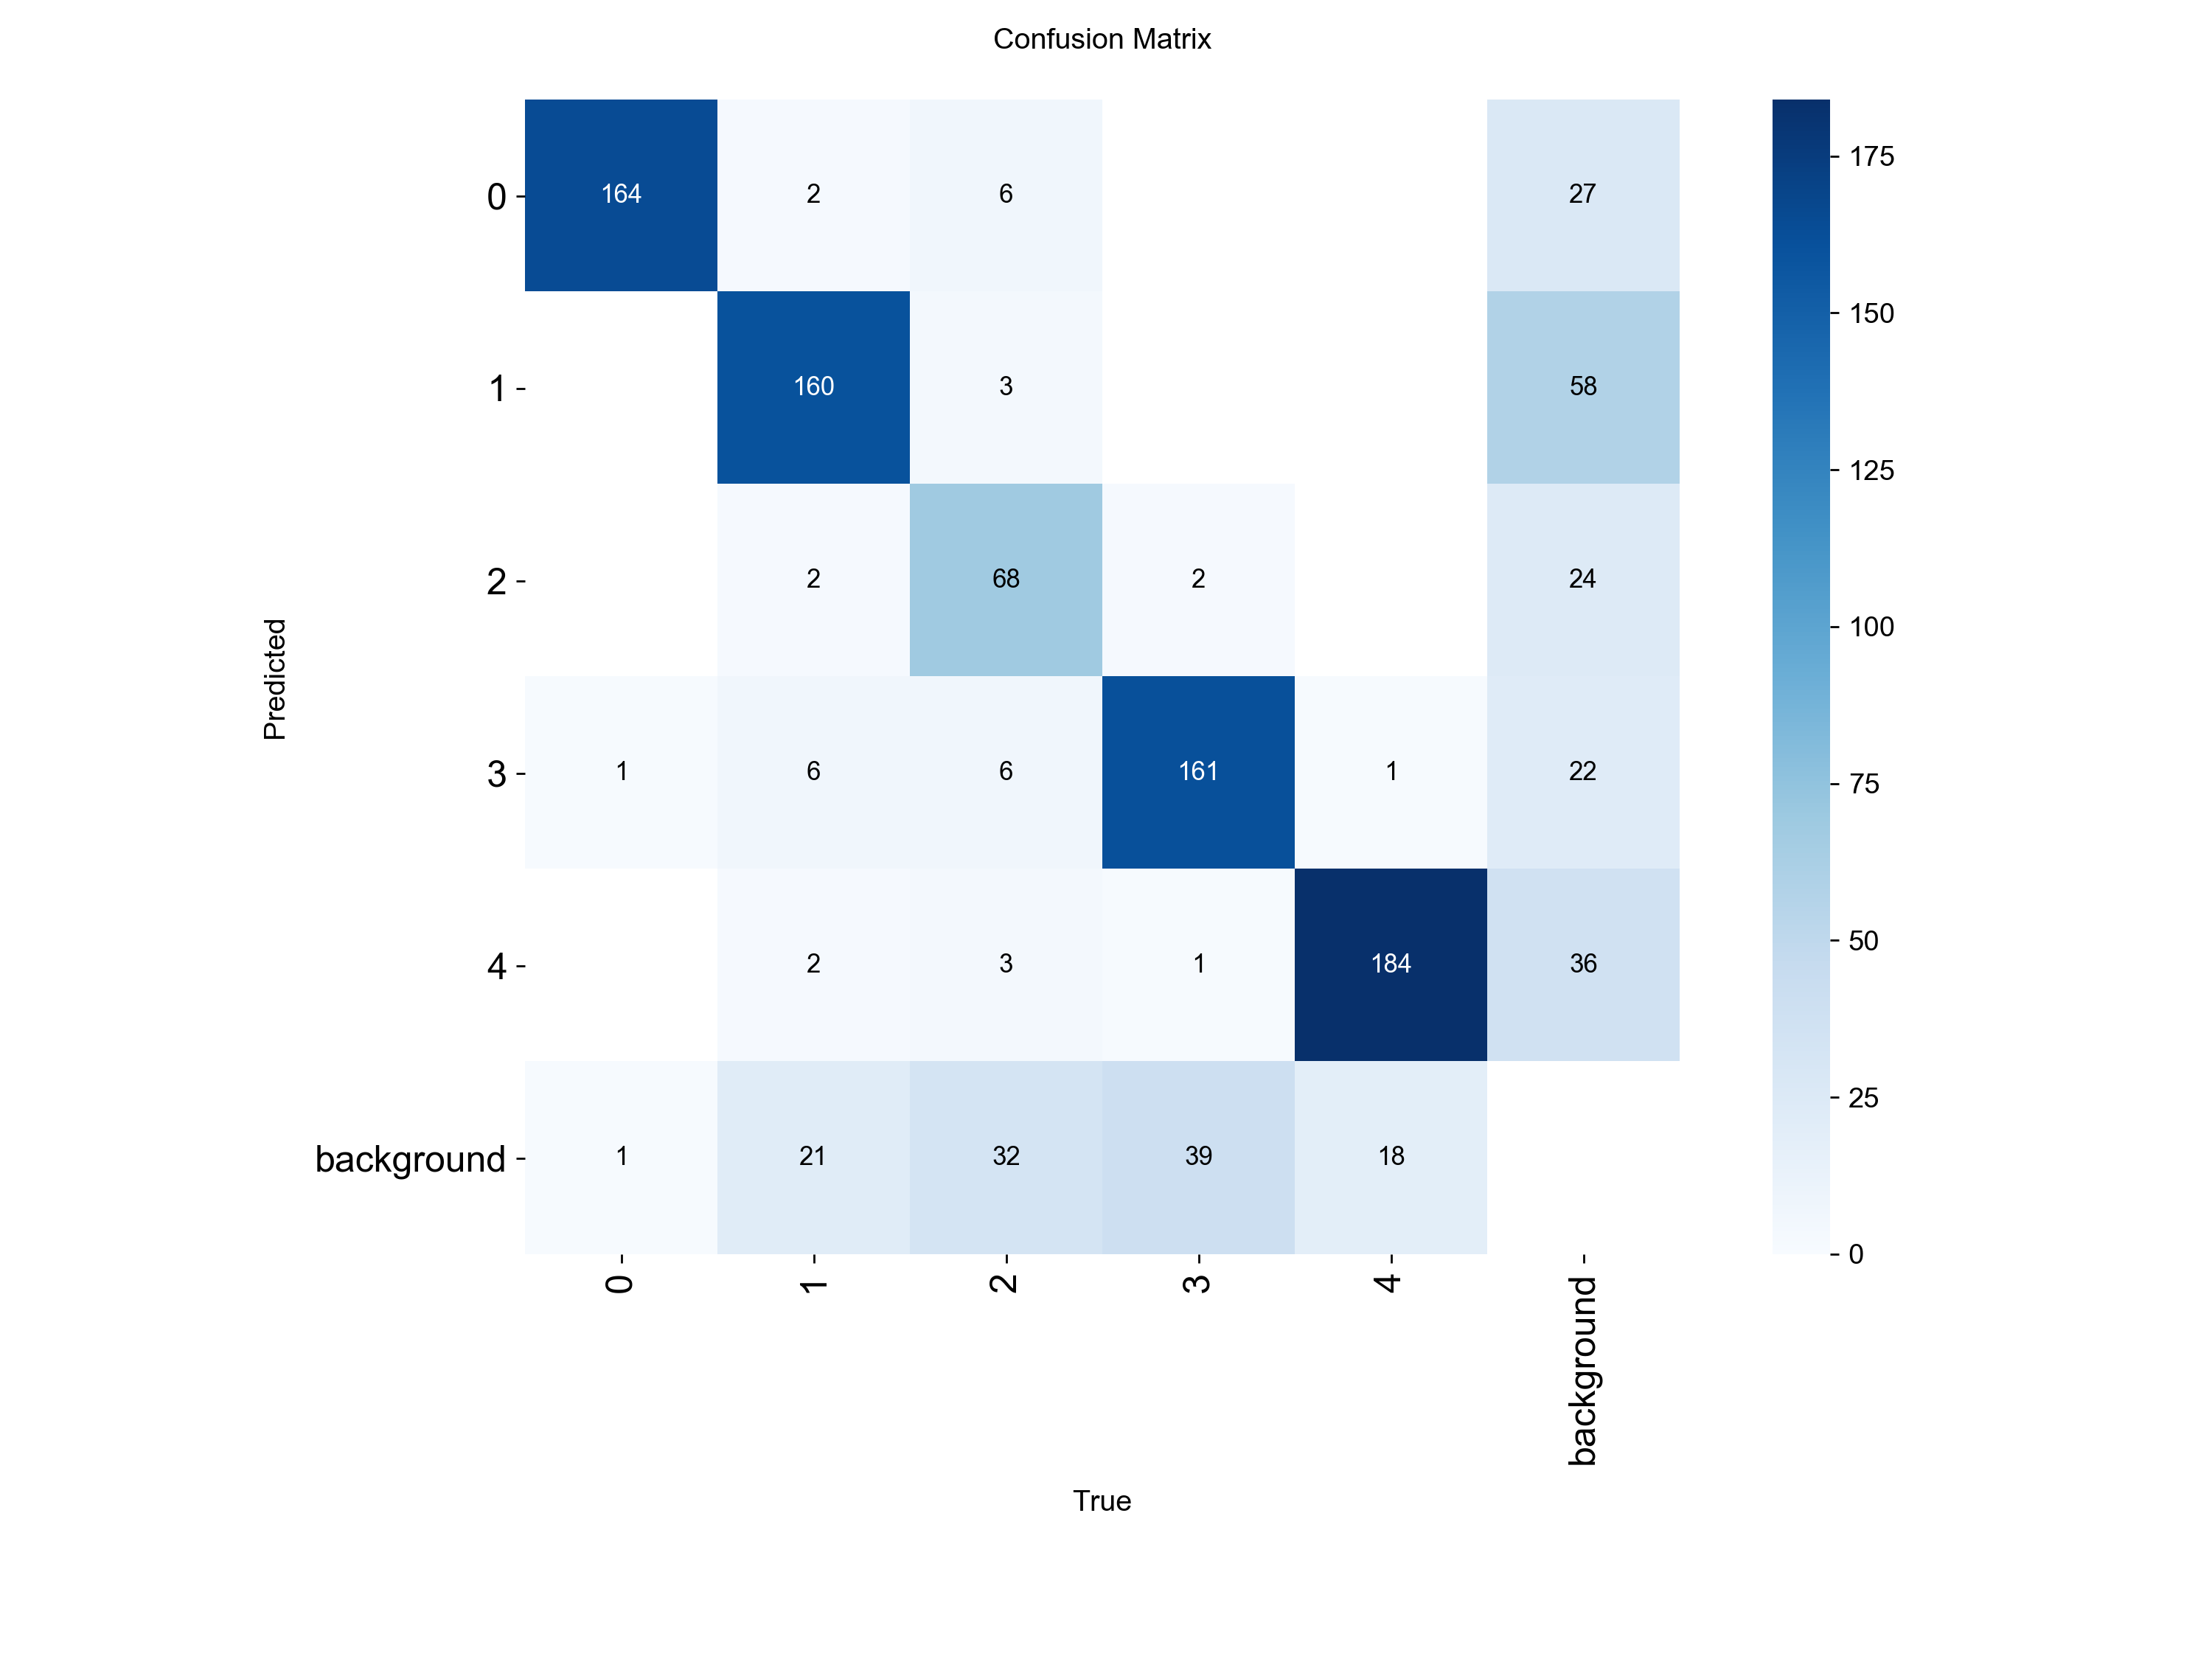

In [50]:
# load confusion matrix image
DisplayImage(filename=f'runs/detect/val/confusion_matrix.png', width=800)

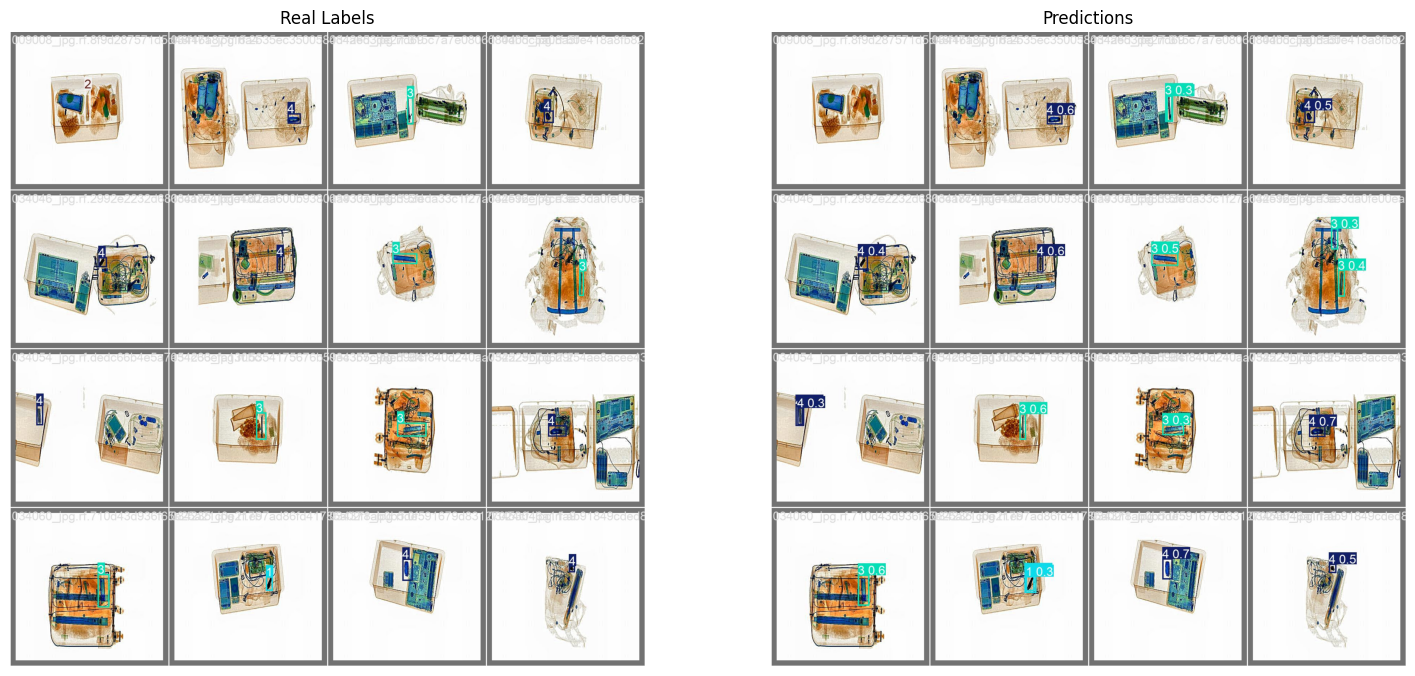

In [54]:
# show some real labesls and predictions
batch0_real_labels_img_path = 'runs/detect/val/val_batch0_labels.jpg'
batch0_predictions_img_path = 'runs/detect/val/val_batch0_pred.jpg'

plt.figure(figsize=(18, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(batch0_real_labels_img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB))
plt.title("Real Labels")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cv2.imread(batch0_predictions_img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB))
plt.title("Predictions")
plt.axis("off")
plt.show()

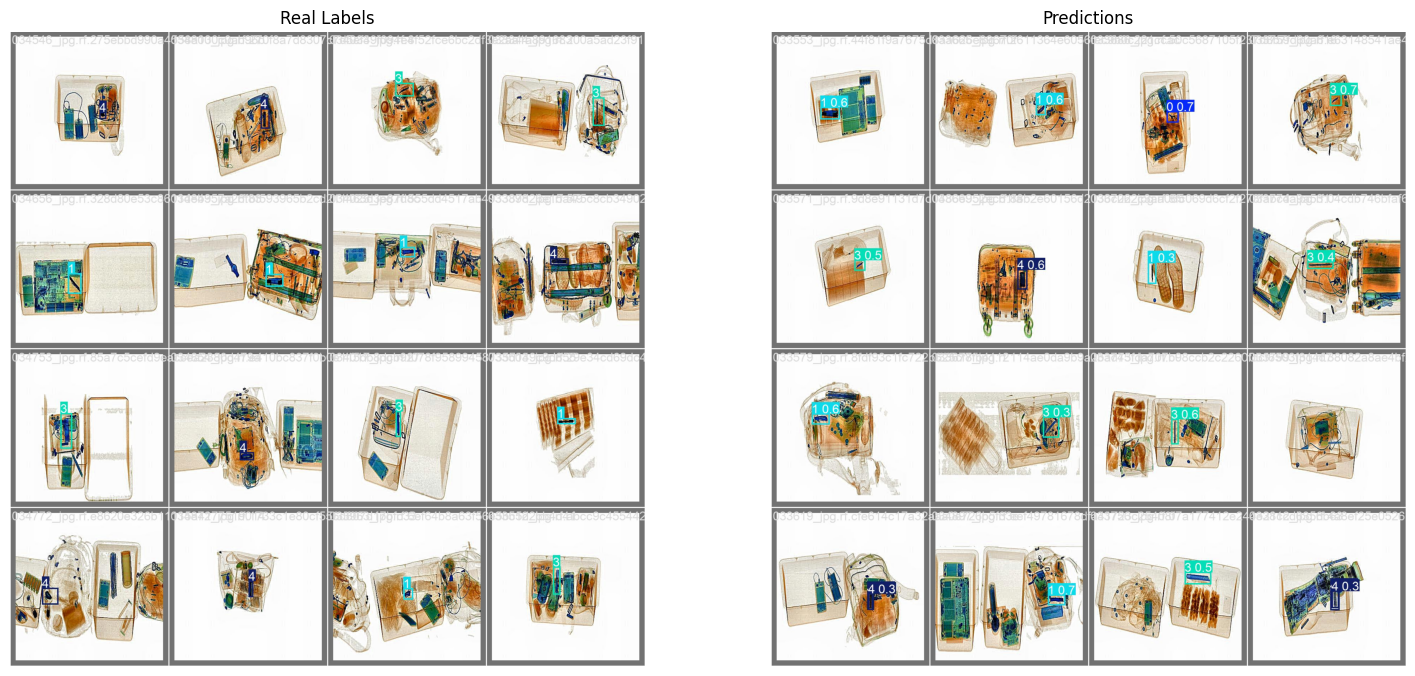

In [57]:
# show some real labesls and predictions
batch0_real_labels_img_path = 'runs/detect/val/val_batch1_labels.jpg'
batch0_predictions_img_path = 'runs/detect/val/val_batch2_pred.jpg'

plt.figure(figsize=(18, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(batch0_real_labels_img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB))
plt.title("Real Labels")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cv2.imread(batch0_predictions_img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB))
plt.title("Predictions")
plt.axis("off")
plt.show()